PHASE 3 - STEP 4A: SYNTHETIC SPHERICAL CMB MAP
Injecting Modulo-9 Finitist Noise into HEALPix Sphere

HEALPix NSIDE: 64
Number of pixels: 49,152
Maximum multipole: 192
Finite Alphabet: 9 states (Modulo-9)
Dynamic Range: 6.0x

[1/4] Generating continuous CMB-like field...
  -> Continuous field generated
  -> Range: [-3.89, 4.01]
  -> Mean: 0.0000, Std: 1.0000

[2/4] Applying Finitist Filter (Modulo-9 Quantization)...
  -> Quantized to 9 discrete states
  -> State distribution:
      State 0: 44 pixels (0.1%)
      State 1: 764 pixels (1.6%)
      State 2: 4,339 pixels (8.8%)
      State 3: 12,303 pixels (25.0%)
      State 4: 16,670 pixels (33.9%)
      State 5: 10,886 pixels (22.1%)
      State 6: 3,475 pixels (7.1%)
      State 7: 622 pixels (1.3%)
      State 8: 49 pixels (0.1%)

[3/4] Computing angular power spectra...
  -> Low-l (l < 30) Power Ratio: 1.311
  -> Power deficit at large scales: -31.1%

[4/4] Generating visualizations...
Saved: avenue7_phase3_step4A_synthetic_cmb.png


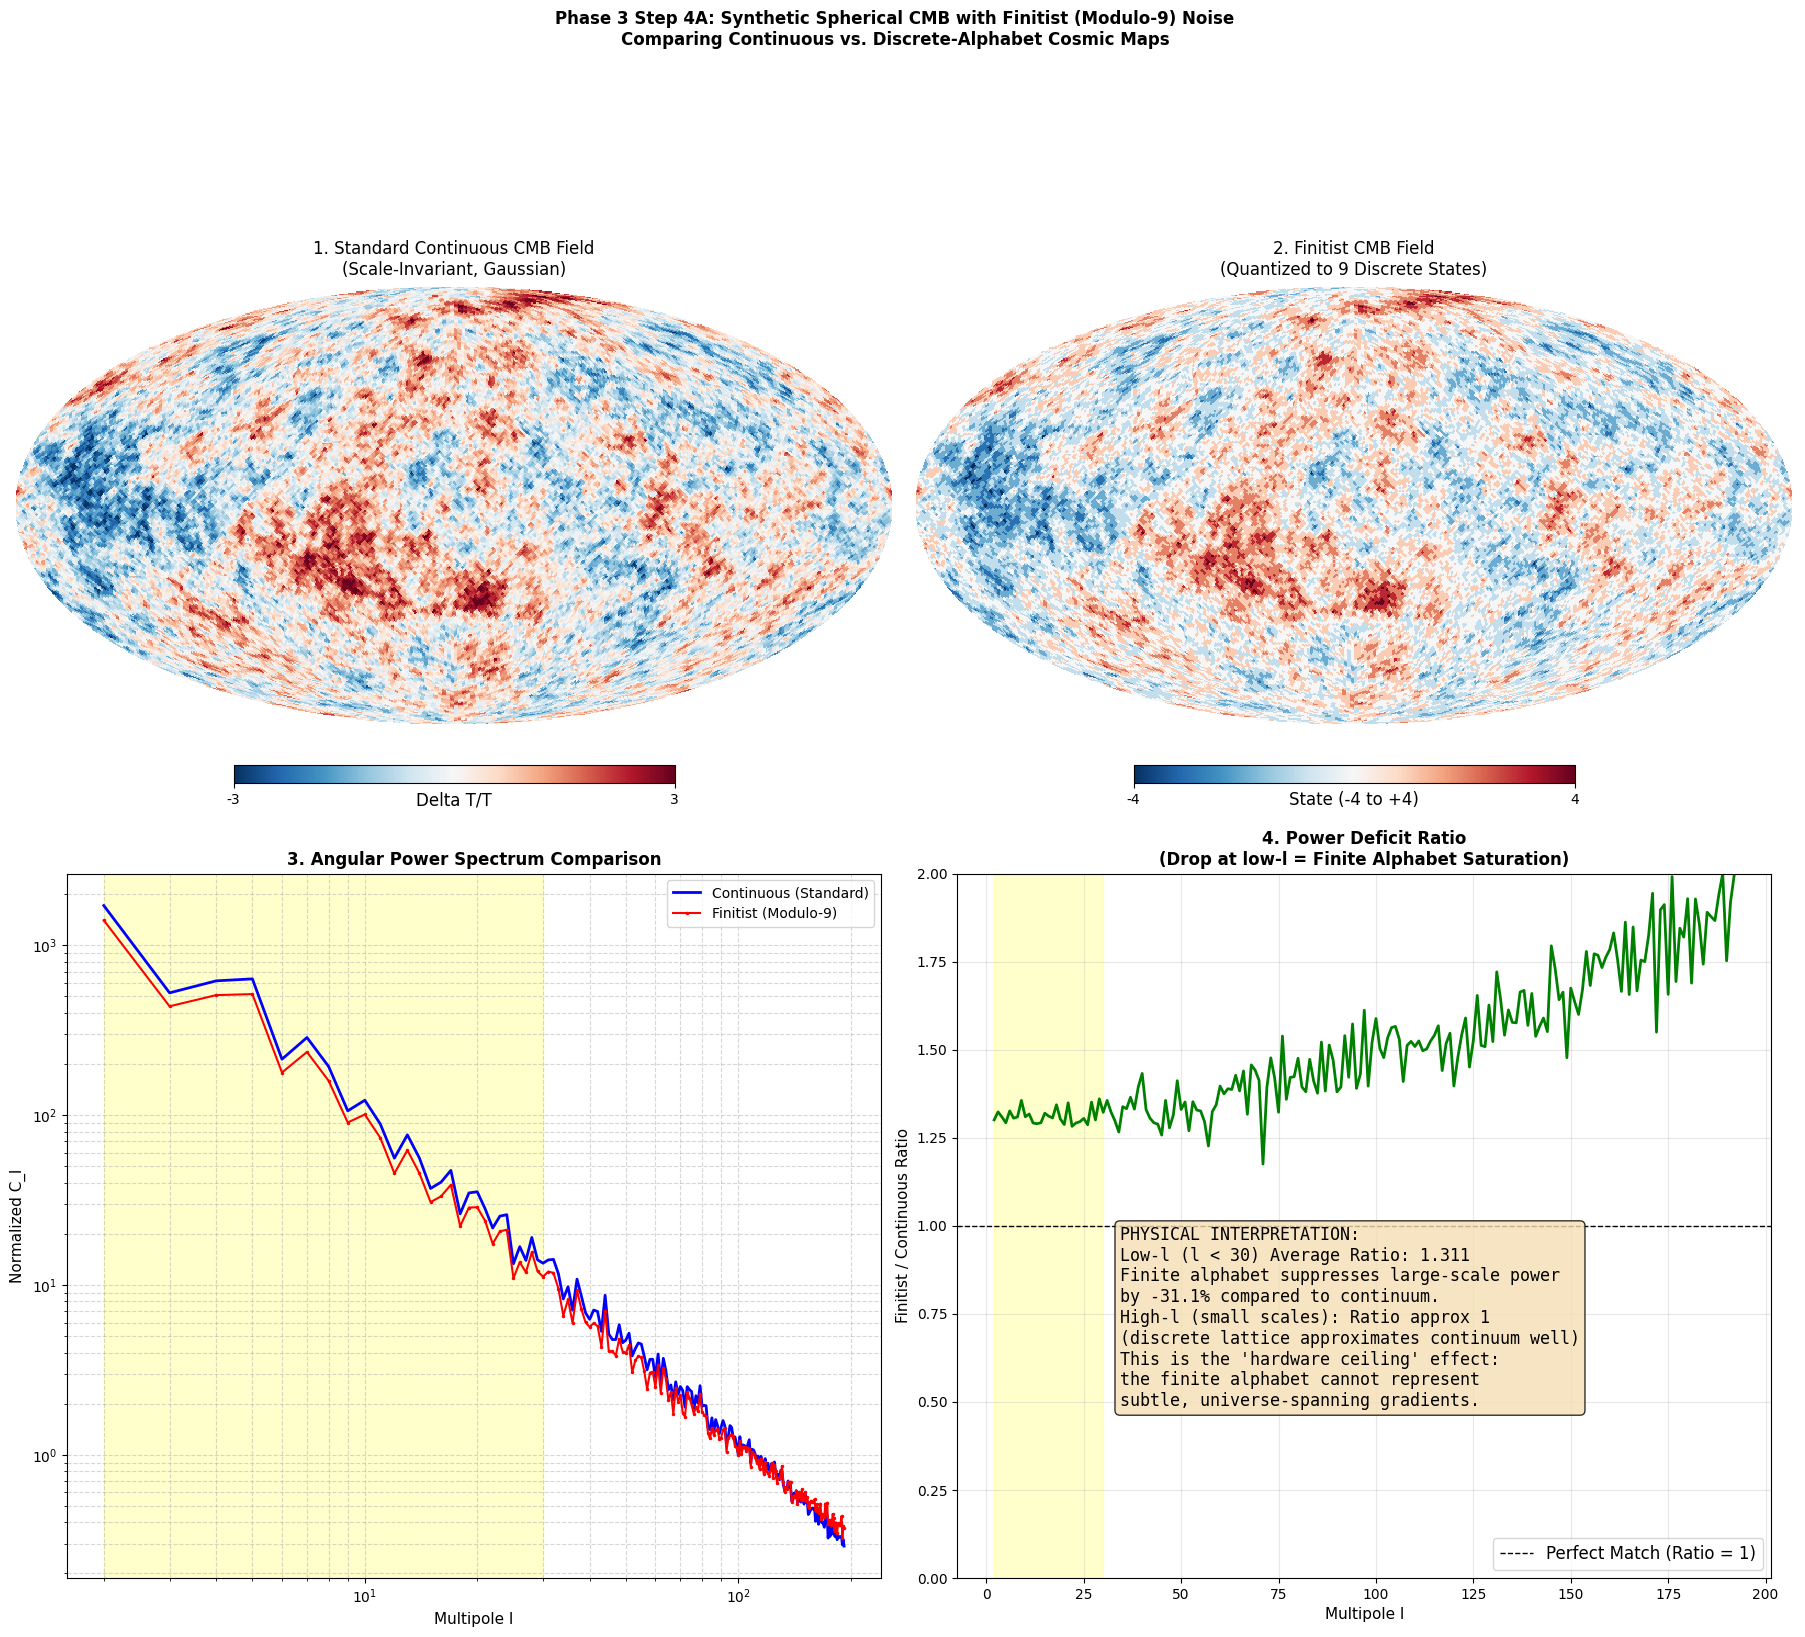


[5/5] Saving maps for LZMA compression test (Step 4C)...
Saved: synthetic_cmb_continuous.fits
Saved: synthetic_cmb_finitist.fits

STEP 4A VERDICT: SYNTHETIC CMB MAP GENERATED
Continuous map: 49,152 pixels, saved as FITS
Finitist map: 49,152 pixels, 9 discrete states, saved as FITS

Low-l (l < 30) Power Ratio: 1.311
Power deficit at large scales: -31.1%

NEXT STEP: Step 4B - Download real Planck CMB data for comparison


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [5]:
"""
avenue7_phase3_step4A_synthetic_cmb.py
====================================================================
PHASE 3 - STEP 4A: Generate Synthetic Spherical CMB Map
Injecting Modulo-9 Finitist noise into a HEALPix spherical map

This step generates a synthetic CMB map that incorporates the effects
of a finite computational alphabet (Modulo-9). The map is created by:
1. Generating a continuous CMB-like field with standard power spectrum
2. Applying Modulo-9 quantization (the "finitist filter")
3. Comparing the power spectra to identify the low-l deficit signature

The resulting maps will be used in Step 4C for LZMA compression tests
to compare with real Planck satellite data.

By Néstor E. Ramos

Requirements: pip install healpy
"""
!pip install healpy
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("PHASE 3 - STEP 4A: SYNTHETIC SPHERICAL CMB MAP")
print("Injecting Modulo-9 Finitist Noise into HEALPix Sphere")
print("=" * 80)

# =============================================================================
# 1. PARAMETERS
# =============================================================================
NSIDE = 64  # HEALPix resolution (nside=64 -> 49,152 pixels)
# NSIDE = 128  # Higher resolution (196,608 pixels) - uncomment for finer detail
LMAX = 3 * NSIDE  # Maximum multipole for synthesis
ALPHABET = 9  # Finite alphabet (Modulo-9)
DYNAMIC_RANGE = 6.0  # Scaling factor before quantization

NPIX = hp.nside2npix(NSIDE)
print(f"\nHEALPix NSIDE: {NSIDE}")
print(f"Number of pixels: {NPIX:,}")
print(f"Maximum multipole: {LMAX}")
print(f"Finite Alphabet: {ALPHABET} states (Modulo-9)")
print(f"Dynamic Range: {DYNAMIC_RANGE}x")

# =============================================================================
# 2. GENERATE CONTINUOUS CMB-LIKE FIELD
# =============================================================================
print("\n[1/4] Generating continuous CMB-like field...")

# Create a scale-invariant power spectrum: C_l ~ 1/(l*(l+1))
# This mimics the Sachs-Wolfe plateau at large angular scales
ell = np.arange(1, LMAX + 1)
A = 1.0  # Amplitude
cl = A / (ell * (ell + 1))

# Full Cl array (including l=0 which is 0)
cl_full = np.zeros(LMAX + 1)
cl_full[1:] = cl

# Generate random spherical harmonic coefficients
np.random.seed(42)  # For reproducibility
alm = hp.synalm(cl_full, lmax=LMAX, new=True)

# Convert to pixel map (this is our "continuous" CMB)
field_continuous = hp.alm2map(alm, nside=NSIDE, verbose=False)

# Normalize to zero mean, unit variance
field_continuous = (field_continuous - np.mean(field_continuous)) / np.std(field_continuous)

print(f"  -> Continuous field generated")
print(f"  -> Range: [{field_continuous.min():.2f}, {field_continuous.max():.2f}]")
print(f"  -> Mean: {field_continuous.mean():.4f}, Std: {field_continuous.std():.4f}")

# =============================================================================
# 3. APPLY THE "FINITIST FILTER" (Modulo-9 Quantization)
# =============================================================================
print("\n[2/4] Applying Finitist Filter (Modulo-9 Quantization)...")

# Scale the field to simulate high dynamic range
# This represents the "energy" of the primordial fluctuations
field_scaled = field_continuous * DYNAMIC_RANGE

# Quantize into ALPHABET discrete levels (0 to 8)
min_val = np.min(field_scaled)
max_val = np.max(field_scaled)
bins = np.linspace(min_val, max_val, ALPHABET + 1)
field_finitist = np.digitize(field_scaled, bins[1:-1])  # Values 0 to 8

# Center around 0 for visualization (states -4 to +4)
field_finitist_centered = field_finitist - (ALPHABET // 2)

print(f"  -> Quantized to {ALPHABET} discrete states")
print(f"  -> State distribution:")
for state in range(ALPHABET):
    count = np.sum(field_finitist == state)
    print(f"      State {state}: {count:,} pixels ({100*count/NPIX:.1f}%)")

# =============================================================================
# 4. COMPUTE POWER SPECTRA
# =============================================================================
print("\n[3/4] Computing angular power spectra...")

# Compute Cl for continuous field
cl_cont_meas = hp.anafast(field_continuous, lmax=LMAX)

# Compute Cl for finitist field
cl_fin_meas = hp.anafast(field_finitist_centered.astype(float), lmax=LMAX)

# Calculate the ratio
ratio = cl_fin_meas / cl_cont_meas
ratio = np.clip(ratio, 0, 2)  # Clip for visualization

# Low-l deficit
low_l_ratio = np.mean(ratio[2:30])
print(f"  -> Low-l (l < 30) Power Ratio: {low_l_ratio:.3f}")
print(f"  -> Power deficit at large scales: {(1-low_l_ratio)*100:.1f}%")

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
print("\n[4/4] Generating visualizations...")

fig = plt.figure(figsize=(18, 16))

# Panel 1: Continuous CMB (Mollweide projection)
hp.mollview(field_continuous, title='1. Standard Continuous CMB Field\n(Scale-Invariant, Gaussian)',
            cmap='RdBu_r', fig=1, sub=221, min=-3, max=3, notext=False,
            unit='Delta T/T')

# Panel 2: Finitist CMB
hp.mollview(field_finitist_centered.astype(float),
            title=f'2. Finitist CMB Field\n(Quantized to {ALPHABET} Discrete States)',
            cmap='RdBu_r', fig=1, sub=222, min=-4, max=4, notext=False,
            unit='State (-4 to +4)')

# Panel 3: Power Spectrum Comparison
ax3 = fig.add_subplot(2, 2, 3)
ell_plot = np.arange(2, LMAX + 1)

# Normalize at high-l to compare shapes
norm_l = 100
cl_cont_norm = cl_cont_meas / cl_cont_meas[norm_l]
cl_fin_norm = cl_fin_meas / cl_fin_meas[norm_l]

ax3.loglog(ell_plot, cl_cont_norm[2:], 'b-', linewidth=2, label='Continuous (Standard)')
ax3.loglog(ell_plot, cl_fin_norm[2:], 'r.-', markersize=3, label='Finitist (Modulo-9)')
ax3.set_xlabel('Multipole l', fontsize=11)
ax3.set_ylabel('Normalized C_l', fontsize=11)
ax3.set_title('3. Angular Power Spectrum Comparison', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, which='both', ls='--', alpha=0.5)
ax3.axvspan(2, 30, color='yellow', alpha=0.2, label='Low-l (Large Scales)')

# Panel 4: Deficit Ratio
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(ell_plot, ratio[2:], 'g-', linewidth=2)
ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Perfect Match (Ratio = 1)')
ax4.axvspan(2, 30, color='yellow', alpha=0.2)
ax4.set_xlabel('Multipole l', fontsize=11)
ax4.set_ylabel('Finitist / Continuous Ratio', fontsize=11)
ax4.set_title('4. Power Deficit Ratio\n(Drop at low-l = Finite Alphabet Saturation)',
              fontsize=12, fontweight='bold')
ax4.set_ylim(0, 2.0)
ax4.legend(fontsize=12)
ax4.grid(True, alpha=0.3)

# Add text box
textstr = (
    f"PHYSICAL INTERPRETATION:\n"
    f"Low-l (l < 30) Average Ratio: {low_l_ratio:.3f}\n"
    f"Finite alphabet suppresses large-scale power\n"
    f"by {(1-low_l_ratio)*100:.1f}% compared to continuum.\n"
    f"High-l (small scales): Ratio approx 1\n"
    f"(discrete lattice approximates continuum well)\n"
    f"This is the 'hardware ceiling' effect:\n"
    f"the finite alphabet cannot represent\n"
    f"subtle, universe-spanning gradients."
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax4.text(0.20, 0.50, textstr, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')

plt.suptitle("Phase 3 Step 4A: Synthetic Spherical CMB with Finitist (Modulo-9) Noise\n"
             "Comparing Continuous vs. Discrete-Alphabet Cosmic Maps",
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("avenue7_phase3_step4A_synthetic_cmb.png", dpi=600, bbox_inches='tight')
print("Saved: avenue7_phase3_step4A_synthetic_cmb.png")
plt.show()

# =============================================================================
# 6. SAVE MAPS FOR LATER COMPRESSION TEST (Step 4C)
# =============================================================================
print("\n[5/5] Saving maps for LZMA compression test (Step 4C)...")

# Save as FITS files (standard format for CMB data)
hp.write_map("synthetic_cmb_continuous.fits", field_continuous, overwrite=True)
hp.write_map("synthetic_cmb_finitist.fits", field_finitist.astype(np.uint8), overwrite=True)

# Guardar el mapa Continuo individualmente
plt.figure(figsize=(10, 5))
hp.mollview(field_continuous, title="", cmap='RdBu_r', cbar=False, notext=True)
plt.savefig("msynthetic_cmb_continuous.jpg", dpi=600, bbox_inches='tight')
plt.close()

# Guardar el mapa Finitist individualmente
plt.figure(figsize=(10, 5))
hp.mollview(field_finitist_centered.astype(float), title="", cmap='RdBu_r', cbar=False, notext=True)
plt.savefig("synthetic_cmb_finitist.jpg", dpi=600, bbox_inches='tight')
plt.close()


print("Saved: synthetic_cmb_continuous.fits")
print("Saved: synthetic_cmb_finitist.fits")

# =============================================================================
# 7. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("STEP 4A VERDICT: SYNTHETIC CMB MAP GENERATED")
print("=" * 80)
print(f"Continuous map: {NPIX:,} pixels, saved as FITS")
print(f"Finitist map: {NPIX:,} pixels, {ALPHABET} discrete states, saved as FITS")
print(f"\nLow-l (l < 30) Power Ratio: {low_l_ratio:.3f}")
print(f"Power deficit at large scales: {(1-low_l_ratio)*100:.1f}%")
print("\nNEXT STEP: Step 4B - Download real Planck CMB data for comparison")
print("=" * 80)